In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots to look clean and professional
sns.set_theme(style="whitegrid")

# Load your custom dataset
df = pd.read_csv(r"C:\Users\Admin\churn-prediction\Dataset\telco_with_all_features.csv")

# Clean hidden empty string spaces in TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset loaded safely with {df.shape[0]} rows and {df.shape[1]} columns!")


Dataset loaded safely with 7043 rows and 26 columns!


# EDA TEXT SUMMARY

In [2]:
# 1. Churn Distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"\n1. Churn Distribution:\n   No: {churn_counts['No']} ({churn_pct['No']:.1f}%)\n   Yes: {churn_counts['Yes']} ({churn_pct['Yes']:.1f}%)")

# 2. Relationship between tenure and churn
avg_tenure = df.groupby('Churn')['tenure'].mean()
print(f"\n2. Average Tenure:\n   Stayed Customers: {avg_tenure['No']:.1f} months\n   Churned Customers: {avg_tenure['Yes']:.1f} months")

# 3. Impact of satisfaction score on churn
avg_sat = df.groupby('Churn')['SatisfactionScore'].mean()
print(f"\n3. Average Satisfaction Score (1-10):\n   Stayed Customers: {avg_sat['No']:.1f}\n   Churned Customers: {avg_sat['Yes']:.1f}")

# 4. Subscription-wise churn analysis
sub_churn = df.groupby('SubscriptionType')['Churn'].value_counts(normalize=True).unstack() * 100
print("\n4. Churn Rate by Subscription Type (%):")
print(sub_churn['Yes'].round(1))



1. Churn Distribution:
   No: 5174 (73.5%)
   Yes: 1869 (26.5%)

2. Average Tenure:
   Stayed Customers: 37.6 months
   Churned Customers: 18.0 months

3. Average Satisfaction Score (1-10):
   Stayed Customers: 5.5
   Churned Customers: 5.5

4. Churn Rate by Subscription Type (%):
SubscriptionType
Basic         26.1
Enterprise    26.4
Premium       27.2
Name: Yes, dtype: float64


#  Churn Distribution Pie Chart

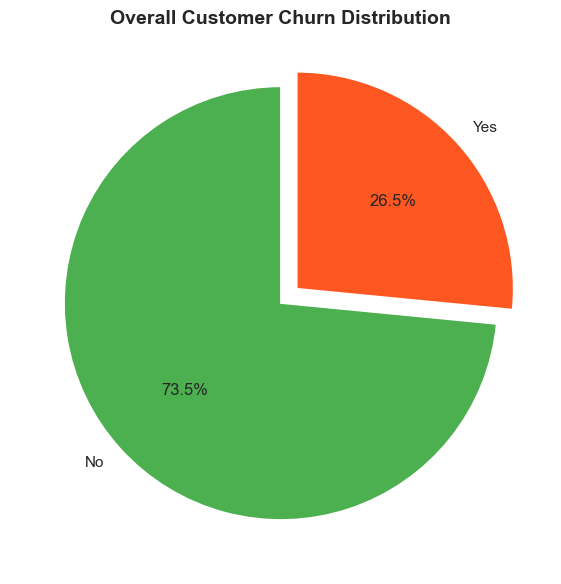

In [3]:
plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#4CAF50', '#FF5722'],
    explode=(0, 0.1)
)
plt.title("Overall Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Bar Chart of Churn by Subscription Type**

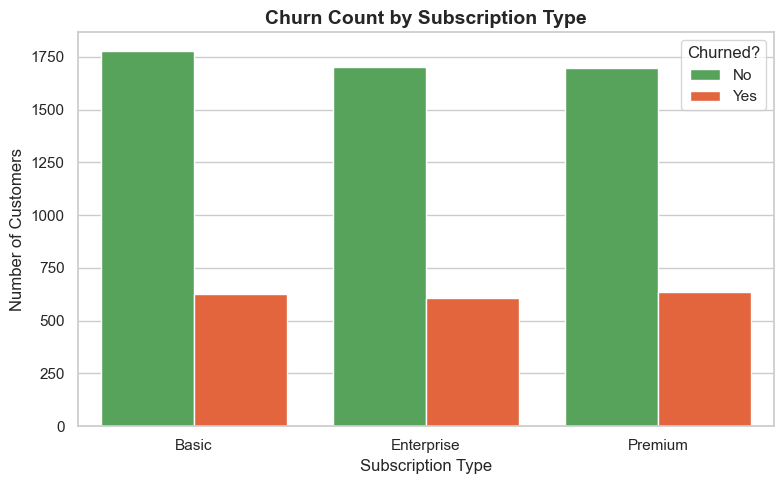

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='SubscriptionType', hue='Churn', palette=['#4CAF50', '#FF5722'])
plt.title("Churn Count by Subscription Type", fontsize=14, fontweight='bold')
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churned?")
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

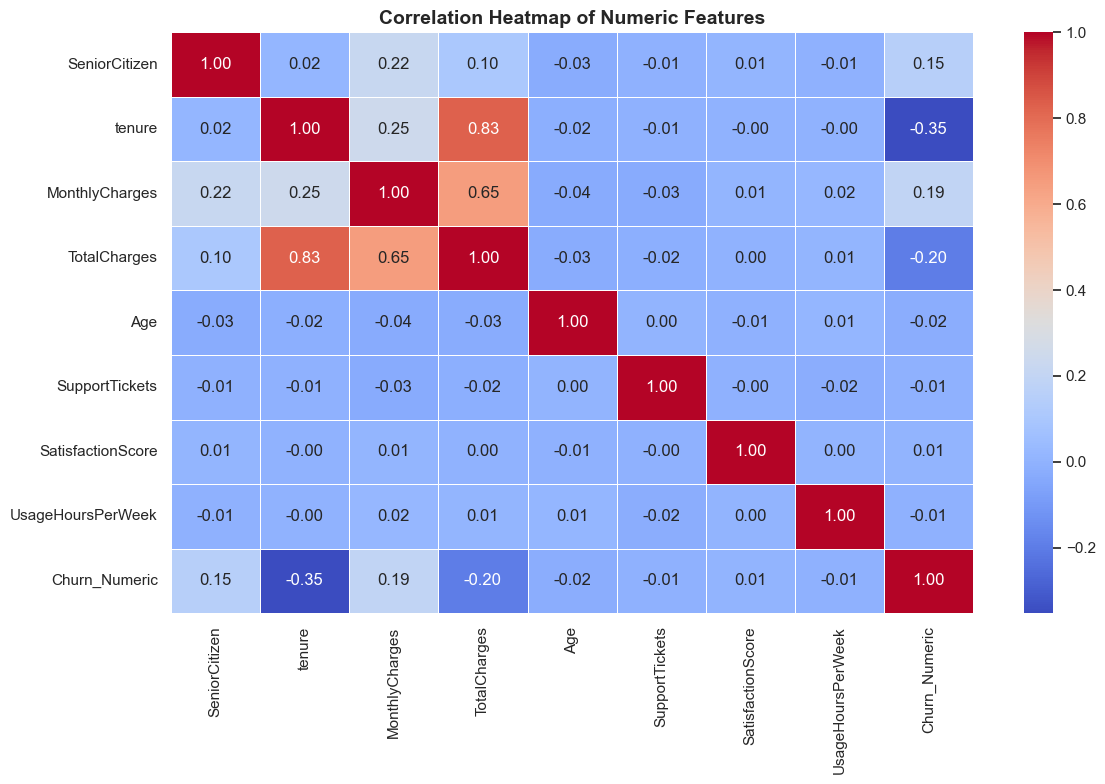

In [5]:
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation mapping
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()
# Map Churn to 0/1 temporarily just to see it on the heatmap
numeric_df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Histogram of Monthly Charges**

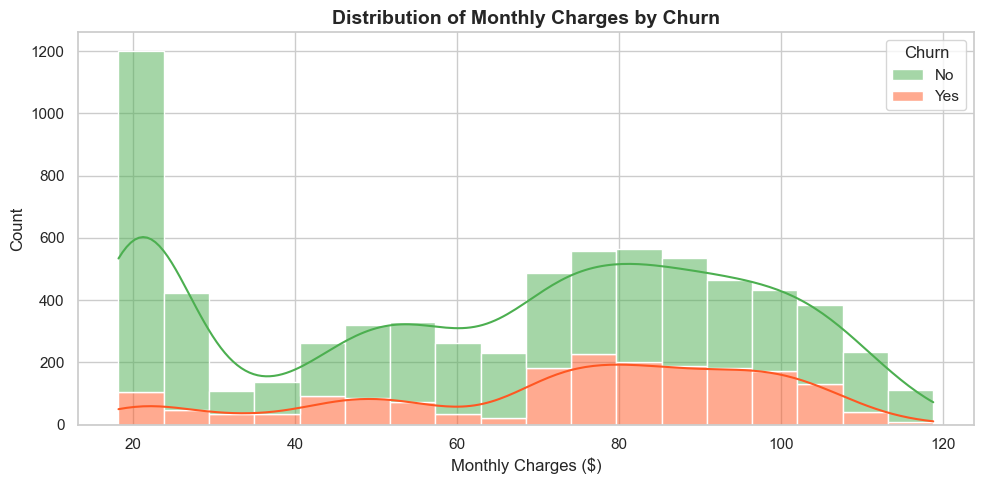

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, 
    x='MonthlyCharges', 
    hue='Churn', 
    kde=True, 
    multiple='stack', 
    palette=['#4CAF50', '#FF5722']
)
plt.title("Distribution of Monthly Charges by Churn", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# **Satisfaction Score vs Churn**

C:\Users\Admin\AppData\Local\Temp\ipykernel_25192\380740925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='SatisfactionScore', palette=['#4CAF50', '#FF5722'])


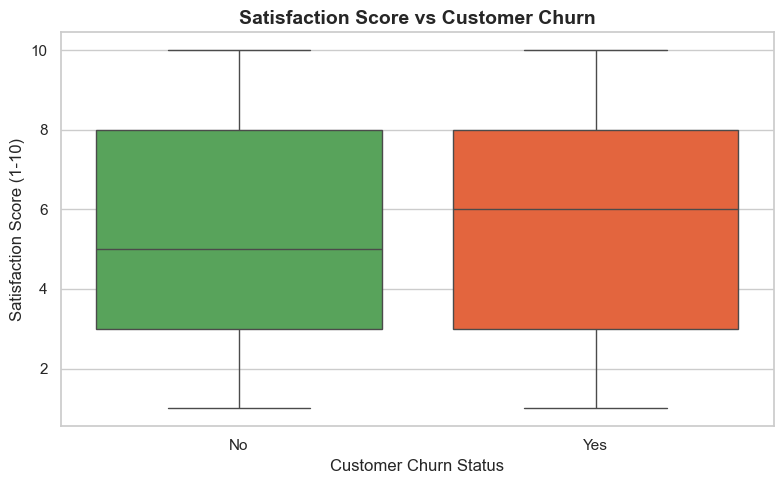

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='SatisfactionScore', palette=['#4CAF50', '#FF5722'])
plt.title("Satisfaction Score vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Customer Churn Status")
plt.ylabel("Satisfaction Score (1-10)")
plt.tight_layout()
plt.show()


# **Satisfaction Score Distribution**

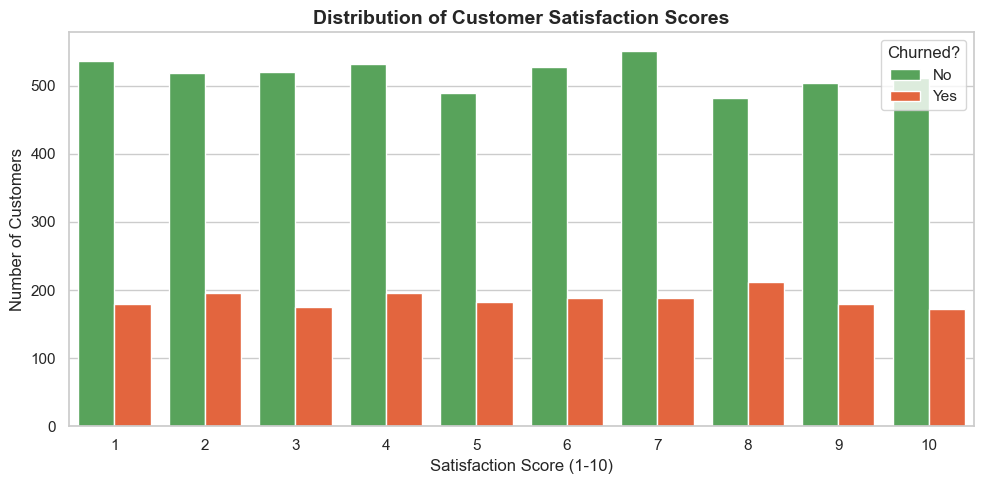

In [8]:
plt.figure(figsize=(10, 5))
# Create a count plot to see exactly how many people gave each rating (1 to 10)
sns.countplot(
    data=df, 
    x='SatisfactionScore', 
    hue='Churn', 
    palette=['#4CAF50', '#FF5722']
)
plt.title("Distribution of Customer Satisfaction Scores", fontsize=14, fontweight='bold')
plt.xlabel("Satisfaction Score (1-10)")
plt.ylabel("Number of Customers")
plt.legend(title="Churned?")
plt.tight_layout()
plt.show()


# **Customer Usage Analysis**

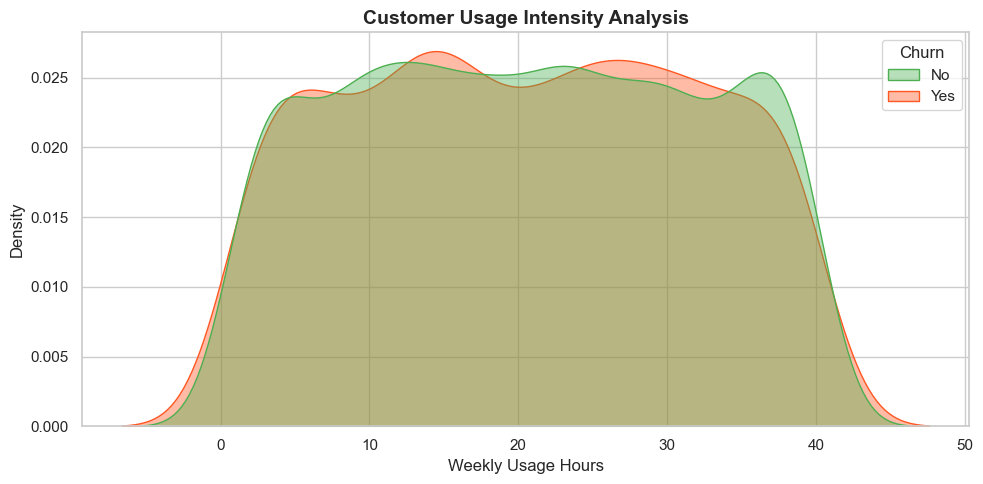

In [9]:
plt.figure(figsize=(10, 5))
# Use a smoothed line plot to compare weekly usage patterns
sns.kdeplot(
    data=df, 
    x='UsageHoursPerWeek', 
    hue='Churn', 
    fill=True, 
    common_norm=False, 
    palette=['#4CAF50', '#FF5722'], 
    alpha=0.4
)
plt.title("Customer Usage Intensity Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Weekly Usage Hours")
plt.ylabel("Density")
plt.tight_layout()
plt.show()
